In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the Titanic datasets

train_df = pd.read_csv("train (1).csv")
test_df = pd.read_csv("test (1).csv")

print("Train Dataset:")
display(train_df.head())

print("\nTest Dataset:")
display(test_df.head())

Train Dataset:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Test Dataset:


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [3]:
# Check the shape of both datasets

print("Train dataset shape:", train_df.shape)
print("Test dataset shape:", test_df.shape)

print("\nMissing values in Train dataset:")
print(train_df.isnull().sum())

print("\nMissing values in Test dataset:")
print(test_df.isnull().sum())

Train dataset shape: (891, 12)
Test dataset shape: (418, 11)

Missing values in Train dataset:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Missing values in Test dataset:
PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


In [4]:
# Select input features and target

features = ["Pclass", "Age", "SibSp", "Parch", "Fare"]

X = train_df[features]
y = train_df["Survived"]

print("Features (X):")
display(X.head())

print("\nTarget (y):")
display(y.head())

Features (X):


,Pclass,Age,SibSp,Parch,Fare
0,3,22.0,1,0,7.2500
1,1,38.0,1,0,71.2833
2,3,26.0,0,0,7.9250
3,1,35.0,1,0,53.1000
4,3,35.0,0,0,8.0500



Target (y):


,Survived
0,0
1,1
2,1
3,1
4,0


In [5]:
# Make a copy of X so the original data remains unchanged
X = X.copy()

# Fill missing Age and Fare values with their median
X["Age"] = X["Age"].fillna(X["Age"].median())
X["Fare"] = X["Fare"].fillna(X["Fare"].median())

# Check missing values again
print("Missing values after preprocessing:")
print(X.isnull().sum())

Missing values after preprocessing:
Pclass    0
Age       0
SibSp     0
Parch     0
Fare      0
dtype: int64


In [6]:
# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training data: (712, 5)
Testing data: (179, 5)
Training target: (712,)
Testing target: (179,)


In [7]:
# Create the Linear Regression model

model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [8]:
# Make predictions on the test data

y_pred = model.predict(X_test)

print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
[0.2525829  0.41695739 0.29531841 0.64486381 0.29230248 0.69393178
 0.24325321 0.24005188 0.32114556 0.79426957]


In [9]:
# Evaluate the Linear Regression model

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("R2 Score:", r2)

Mean Squared Error (MSE): 0.1869278524055185
R2 Score: 0.2291691996235239


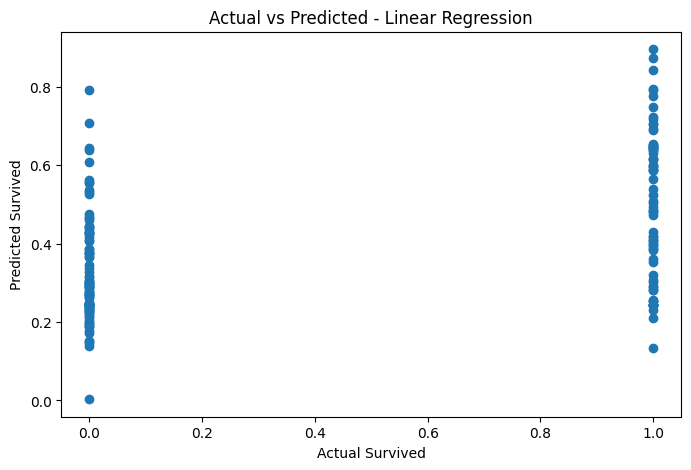

In [10]:
# Plot Actual vs Predicted values

plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Survived")
plt.ylabel("Predicted Survived")
plt.title("Actual vs Predicted - Linear Regression")

plt.show()

In [11]:
# Prepare the original Titanic test dataset

test_features = test_df[features].copy()

# Handle missing values
test_features["Age"] = test_features["Age"].fillna(train_df["Age"].median())
test_features["Fare"] = test_features["Fare"].fillna(train_df["Fare"].median())

# Predict survival
test_predictions = model.predict(test_features)

print("First 10 test predictions:")
print(test_predictions[:10])

First 10 test predictions:
[0.20112351 0.07477873 0.21509957 0.25045841 0.28921375 0.33528203
 0.23017661 0.46735468 0.3077559  0.21241005]


In [12]:
# Convert continuous predictions into 0 or 1

test_survived = (test_predictions >= 0.5).astype(int)

print("First 20 final predictions:")
print(test_survived[:20])

First 20 final predictions:
[0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0]


In [13]:
# Create the final submission DataFrame

submission = pd.DataFrame({
    "PassengerId": test_df["PassengerId"],
    "Survived": test_survived
})

# Save predictions as a CSV file
submission.to_csv("titanic_predictions.csv", index=False)

print("Prediction file created successfully!")
display(submission.head(10))

Prediction file created successfully!


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0
5,897,0
6,898,0
7,899,0
8,900,0
9,901,0
